<div>
Olá, Lucas!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário geral do revisor v1</b> <a class="tocSkip"></a>
<s>
    
Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Comentários sucintos e bem objetivos
- Análises bem detalhadas em cada etapa do projeto
    
Entretanto, deixei alguns comentários em alguns trechos que precisam de ajuste. Peço que trabalhe nesses pontos para avançarmos.
    
Qualquer dúvida, pode contar comigo.   
    
    
**Até breve!**
</s>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e fazer os ajustes sugeridos. Essa versão do seu trabalho ficou muito melhor! Espero que as sugestões sejam relevantes para projetos futuros.
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# 1 Baixando dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/gym_churn_us.csv')

# 2 Análise Exploratória dos dados

In [2]:
# passo 2.1
print('o conjunto de dados está completo.')
df.describe()

o conjunto de dados está completo.


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram carregados corretamente
- Os imports foram feitos corretamente, porém considere executar os comandos em células separadas para isolar a execução do código
- O método `describe()` foi usado para exibir uma amostra do conjunto de dados
</div>

In [3]:
# Passo 2.2
churn_df = df.groupby('Churn').mean()
churn_n, churn_y= churn_df.iloc[0], churn_df.iloc[1] 
print(churn_n)

gender                                 0.510037
Near_Location                          0.873086
Partner                                0.534195
Promo_friends                          0.353522
Phone                                  0.903709
Contract_period                        5.747193
Group_visits                           0.464103
Age                                   29.976523
Avg_additional_charges_total         158.445715
Month_to_end_contract                  5.283089
Lifetime                               4.711807
Avg_class_frequency_total              2.024876
Avg_class_frequency_current_month      2.027882
Name: 0, dtype: float64


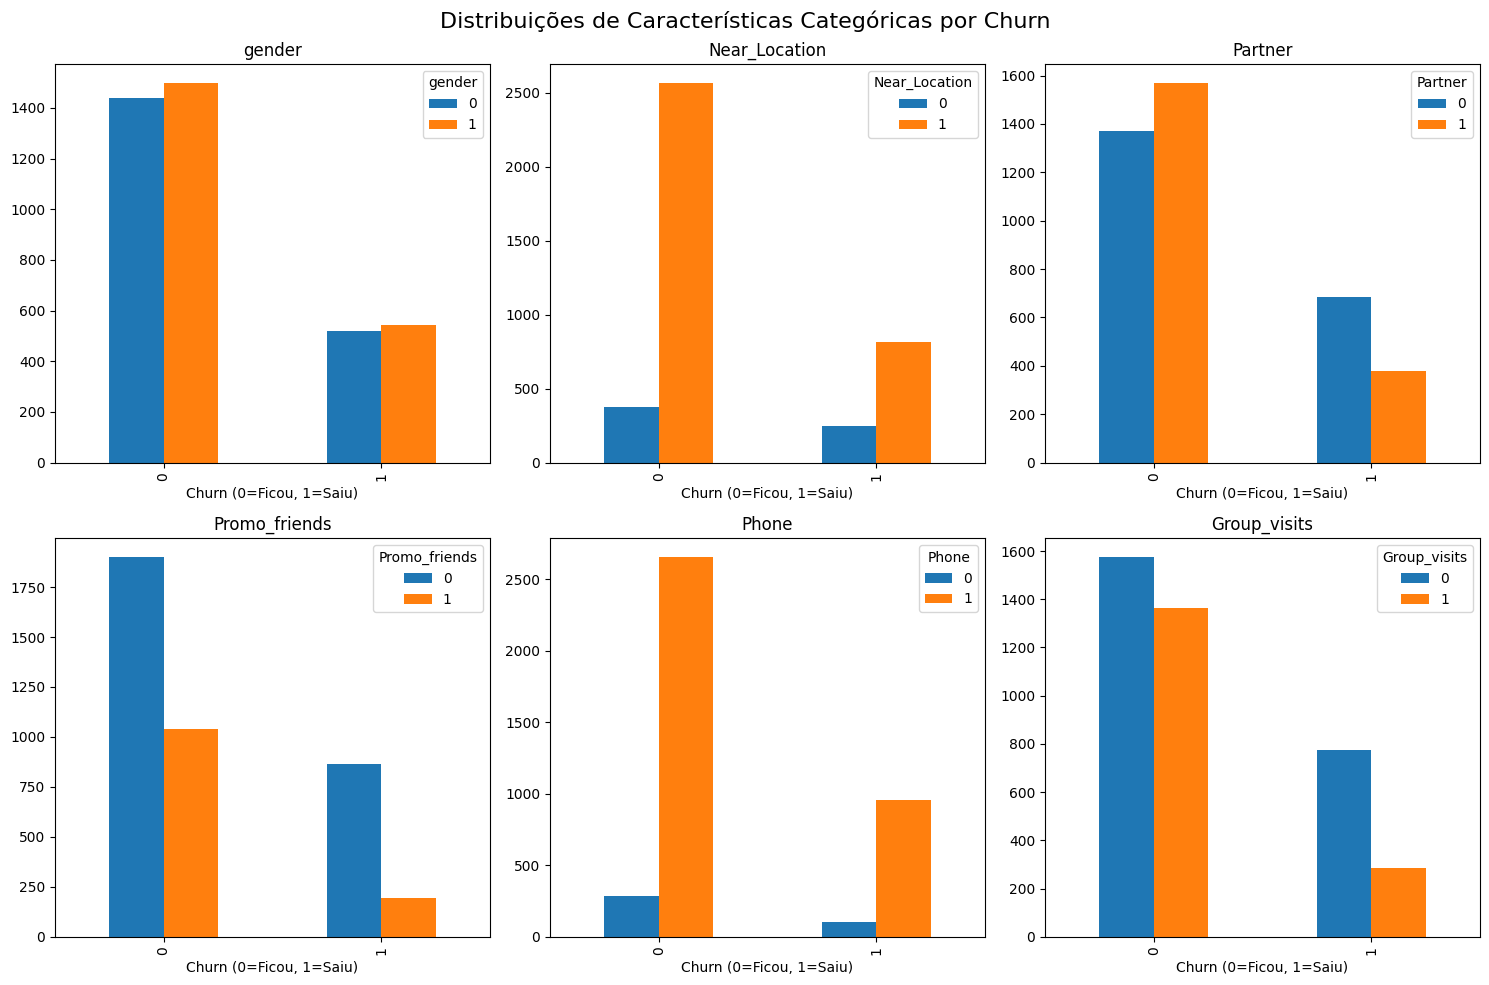

In [4]:
# Passo 2.3
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribuições de Características Categóricas por Churn', fontsize=16)

categorical_features = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']

for i, feature in enumerate(categorical_features):
    row = i // 3
    col = i % 3
    churn_counts = df.groupby(['Churn', feature]).size().unstack()
    churn_counts.plot(kind='bar', ax=axes[row, col])
    axes[row, col].set_title(f'{feature}')
    axes[row, col].set_xlabel('Churn (0=Ficou, 1=Saiu)')
    
plt.tight_layout()
plt.show()

Observando os gráficos de distribuição, identifico que as variáveis mais discriminantes para o churn são:

- Group_visits: Clientes que participam de atividades em grupo apresentam menor taxa de evasão
- Partner: Ter um parceiro na academia reduz significativamente o churn
- Promo_friends: Clientes que vieram por indicação de amigos são mais fiéis

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- <s>Qual a sua conclusão acerca da análise acima?</s>
</div>

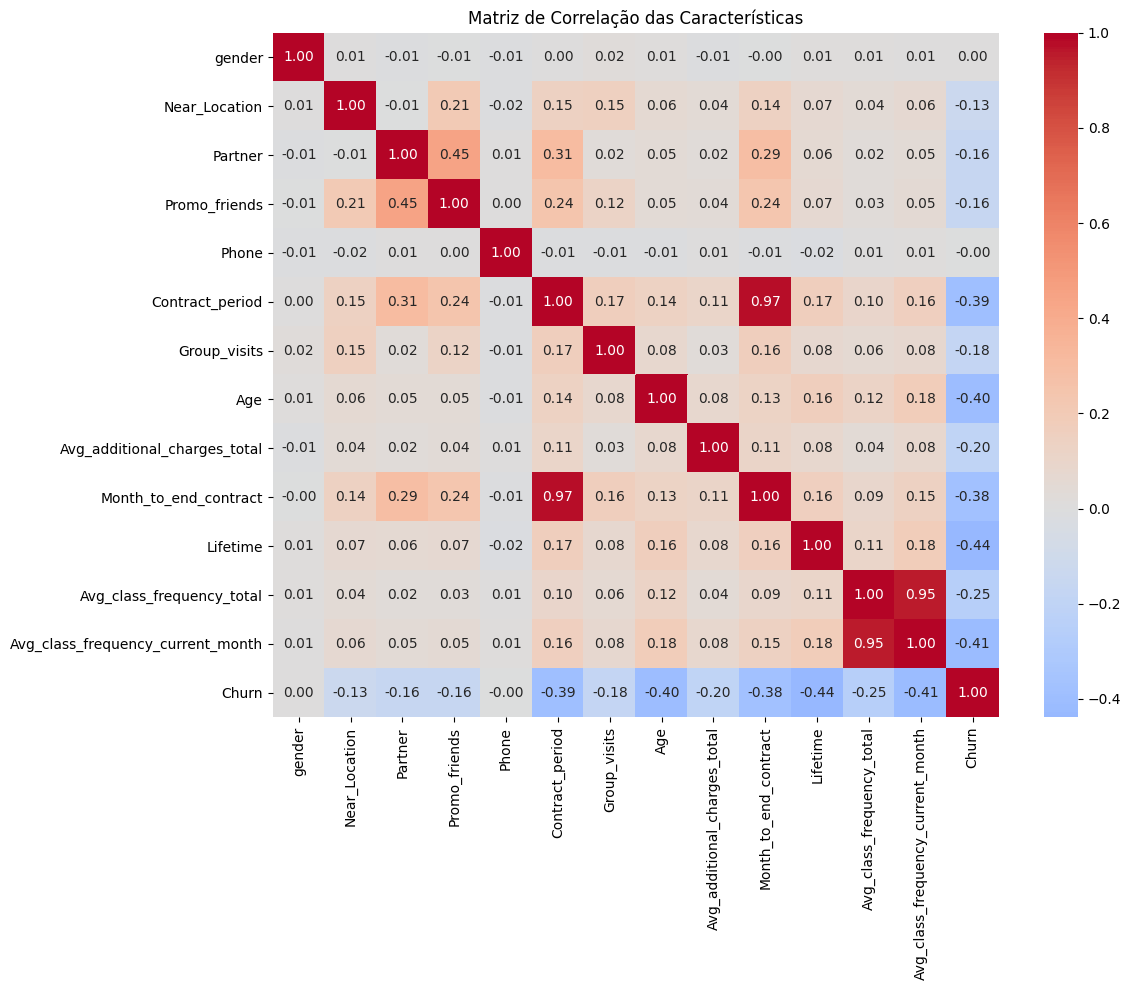

In [5]:
# Passo 2.4
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.title('Matriz de Correlação das Características')
plt.tight_layout()
plt.show()

A matriz de correlação revela que:

- Contract_period e Lifetime têm correlação negativa com churn, confirmando que clientes com contratos mais longos e maior tempo na academia são mais fiéis
- Month_to_end_contract também se correlaciona negativamente, confirmando que clientes próximos ao fim do contrato têm maior risco de sair

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- <s>Qual a sua conclusão acerca da análise acima?</s>
</div>

# 3 Construindo modelo

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [7]:
def print_all_metrics(y_true, y_pred, y_proba, title = 'Métricas de classificação'):
    print(title)
    print('Acurácia: {:.3f}'.format(accuracy_score(y_true, y_pred)))
    print('Precisão: {:.3f}'.format(precision_score(y_true, y_pred)))
    print('Sensibilidade: {:.3f}\n'.format(recall_score(y_true, y_pred)))

X = df.drop('Churn', axis = 1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

lr_model = LogisticRegression(random_state = 0)
lr_model.fit(X_train_st, y_train)
lr_predictions = lr_model.predict(X_test_st)
lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]
print_all_metrics(y_test,
                  lr_predictions,
                  lr_probabilities,
                  title='Métricas para regressão logística:')

rf_model = RandomForestClassifier(random_state = 0)
rf_model.fit(X_train_st, y_train)
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]
print_all_metrics(y_test,
                  rf_predictions,
                  rf_probabilities,
                  title='Métricas para floresta aleatória:')

Métricas para regressão logística:
Acurácia: 0.922
Precisão: 0.854
Sensibilidade: 0.828

Métricas para floresta aleatória:
Acurácia: 0.915
Precisão: 0.839
Sensibilidade: 0.813



O método de regressão logística obteve melhores resultados.

# 4 Agrupando clientes

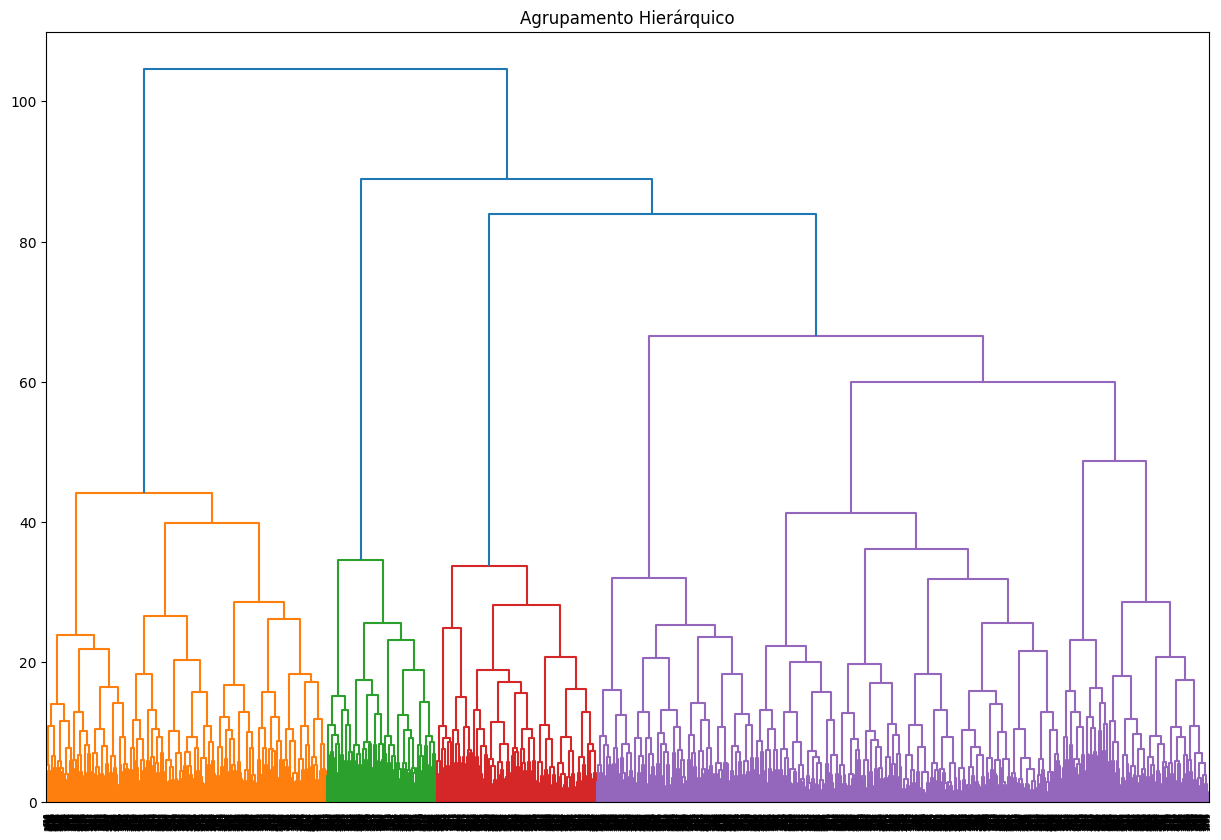

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
x_sc = scaler.fit_transform(X)

linked = linkage(x_sc, method = 'ward')

plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupamento Hierárquico')
plt.show()

cluster
0    0.266839
1    0.257600
2    0.021864
3    0.082558
4    0.561111
Name: Churn, dtype: float64


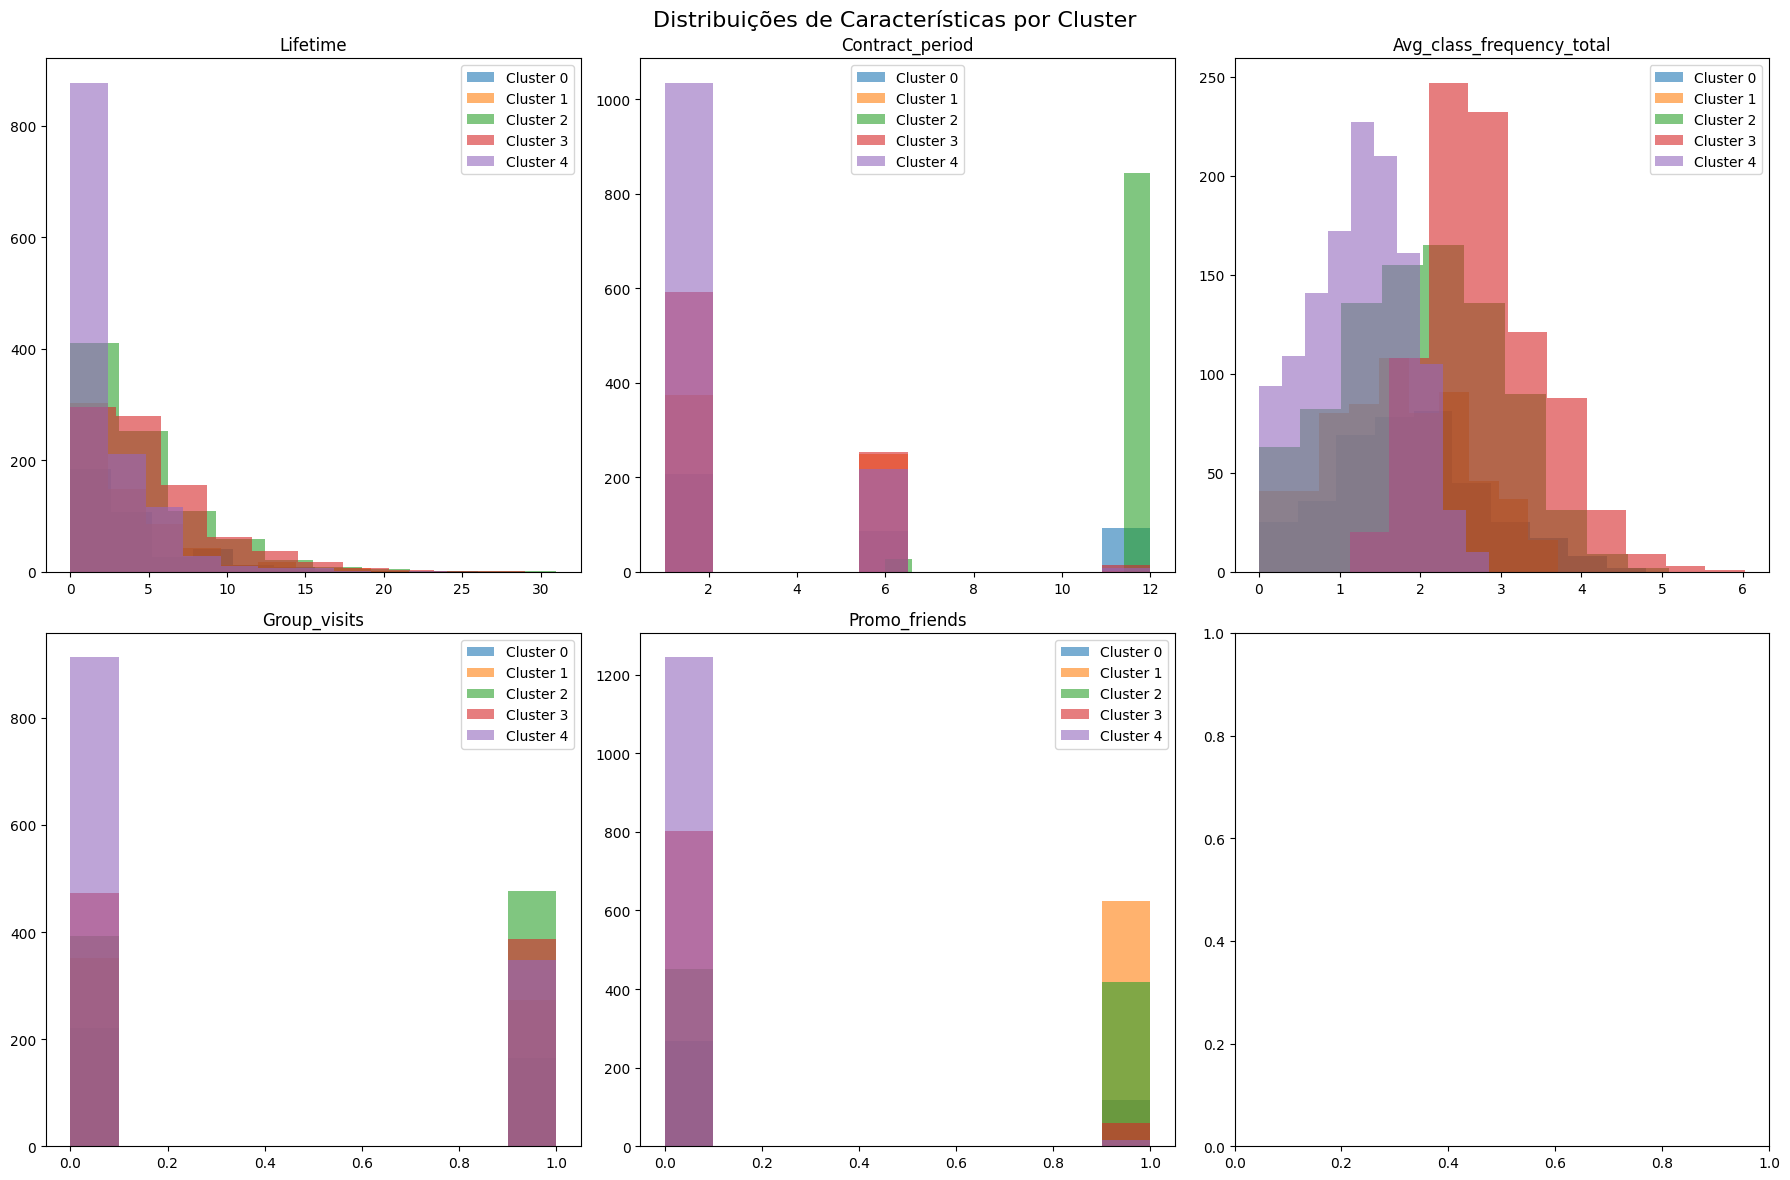

In [9]:
from sklearn.cluster import KMeans
    
km = KMeans(n_clusters=5)
labels = km.fit_predict(x_sc)
df['cluster'] = labels
print(df.groupby(['cluster'])['Churn'].mean())

key_features = ['Lifetime', 'Contract_period', 'Avg_class_frequency_total', 
                'Group_visits', 'Promo_friends']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribuições de Características por Cluster', fontsize=16)

for i, feature in enumerate(key_features):
    row = i // 3
    col = i % 3
    
    for cluster in range(5):
        cluster_data = df[df['cluster'] == cluster][feature]
        axes[row, col].hist(cluster_data, alpha=0.6, label=f'Cluster {cluster}')
    
    axes[row, col].set_title(f'{feature}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

- Cluster 0: 44% de churn, valor alto
- Cluster 1: 2.8% de churn, valor baixo
- Cluster 2: 7% de churn, valor baixo
- Cluster 3: 26.7% de churn, valor médio
- Cluster 4: 52.4% de churn, valor alto

Os clusters com valores mais altos de churn têm em comum o baixo período de contrato, lifetime e group visits, enquanto os clusters com valores baixos de churn demonstram comportamento oposto.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram padronizados
- O agrupamento hierárquico foi executado
- O dendograma foi criado
- A função `linkage()` foi utilizada para construir a matriz de distâncias
- A rotatividade média foi calculada por grupo (`cluster`)
</div>

# 5 Conclusões e Recomendações

Principais conclusões:

Clientes com alto risco de churn possuem:
- Período de contrato baixo (1-2 meses).
- Lifetime baixo (2-3 meses).
- Baixa participação em Group Visits.
- Poucas indicações de amigos.

Enquanto clientes fiéis possuem:
- Período de contrato superior a 6 meses
- Maior Lifetime na academia
- Maior participação em Group Visits

Implementações possíveis em marketing:
- Encorajamento de atividades em grupo (aumentar a participação em Group Vi)
- Programas de indicação (aumentar as indicações)
- Benefícios de fidelidade (aumentar o Lifetime)

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os grupos foram gerados utilizando K-means
- Os clusters foram analisados e as observações foram apresentadas
</div>